<a href="https://colab.research.google.com/github/elemcarames/credit-risk-prediction/blob/main/credit_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load data
df = pd.read_csv('cs-training.csv', index_col=0)

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst rows:")
df.head()

Shape: (150000, 11)

Columns:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

First rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# Exploratory Data Analysis
print("=== Basic Info ===")
print(df.info())

print("\n=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print("\n=== Target Variable Distribution ===")
print(df['SeriousDlqin2yrs'].value_counts())
print(f"\nDefault rate: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

print("\n=== Basic Statistics ===")
df.describe()

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null 

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [4]:
# Data Cleaning
# Impute missing values with median
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# Remove outliers — age 0 is clearly an error
print(f"Age == 0: {(df['age'] == 0).sum()} rows")
df = df[df['age'] > 0]

# Cap extreme outliers in utilization (values > 1 don't make sense)
print(f"Utilization > 1: {(df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()} rows")
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)

print(f"\nFinal shape: {df.shape}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

Age == 0: 1 rows
Utilization > 1: 3321 rows

Final shape: (149999, 11)
Missing values remaining: 0


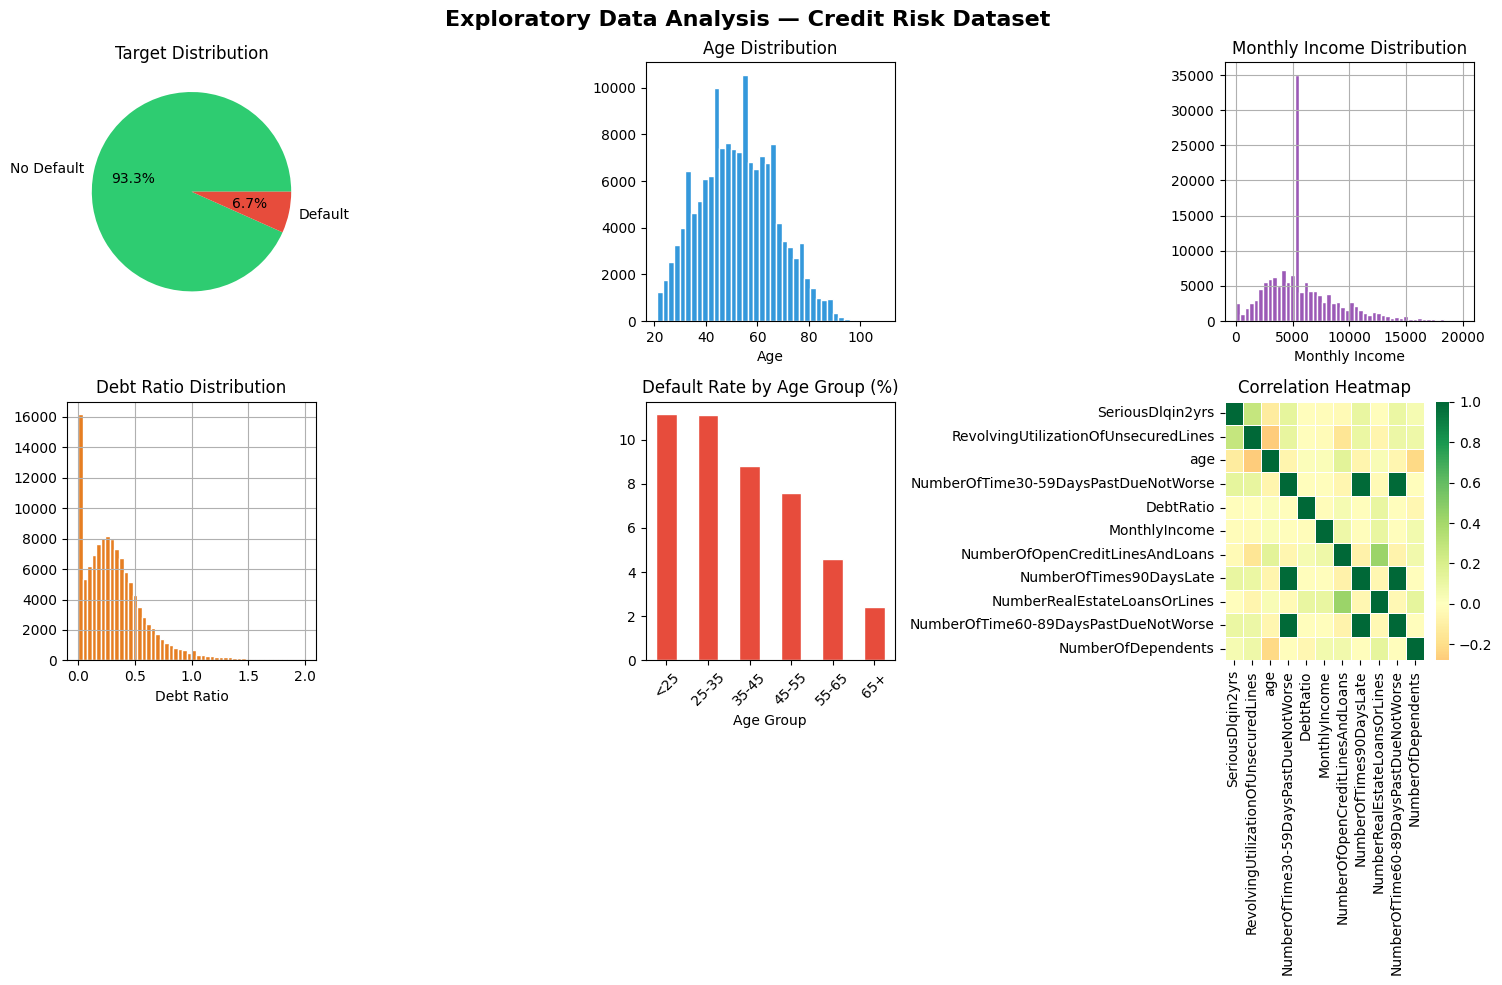

Plots saved!


In [5]:
# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Exploratory Data Analysis — Credit Risk Dataset', fontsize=16, fontweight='bold')

# Target distribution
axes[0,0].pie([139974, 10026], labels=['No Default', 'Default'],
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Target Distribution')

# Age distribution
axes[0,1].hist(df['age'], bins=40, color='#3498db', edgecolor='white')
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')

# Monthly Income distribution
df[df['MonthlyIncome'] < 20000]['MonthlyIncome'].hist(
    bins=50, ax=axes[0,2], color='#9b59b6', edgecolor='white')
axes[0,2].set_title('Monthly Income Distribution')
axes[0,2].set_xlabel('Monthly Income')

# Debt Ratio
df[df['DebtRatio'] < 2]['DebtRatio'].hist(
    bins=50, ax=axes[1,0], color='#e67e22', edgecolor='white')
axes[1,0].set_title('Debt Ratio Distribution')
axes[1,0].set_xlabel('Debt Ratio')

# Default rate by age group
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,45,55,65,100],
                          labels=['<25','25-35','35-45','45-55','55-65','65+'])
default_by_age = df.groupby('age_group')['SeriousDlqin2yrs'].mean() * 100
default_by_age.plot(kind='bar', ax=axes[1,1], color='#e74c3c', edgecolor='white')
axes[1,1].set_title('Default Rate by Age Group (%)')
axes[1,1].set_xlabel('Age Group')
axes[1,1].tick_params(axis='x', rotation=45)

# Correlation heatmap
corr = df.drop('age_group', axis=1).corr()
sns.heatmap(corr, ax=axes[1,2], cmap='RdYlGn', center=0,
            annot=False, linewidths=0.5)
axes[1,2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved!")

In [6]:
# Feature Engineering & Model Training

# Define features and target
X = df.drop(['SeriousDlqin2yrs', 'age_group'], axis=1)
y = df['SeriousDlqin2yrs']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Handle class imbalance with oversampling (SMOTE-like with resample)
X_train_bal = pd.concat([X_train, y_train], axis=1)
majority = X_train_bal[X_train_bal['SeriousDlqin2yrs'] == 0]
minority = X_train_bal[X_train_bal['SeriousDlqin2yrs'] == 1]

minority_upsampled = resample(minority, replace=True,
                               n_samples=len(majority), random_state=42)
balanced = pd.concat([majority, minority_upsampled])

X_train_bal = balanced.drop('SeriousDlqin2yrs', axis=1)
y_train_bal = balanced['SeriousDlqin2yrs']

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")
print(f"Class balance after oversampling: {y_train_bal.value_counts().to_dict()}")

Training set size: (223956, 10)
Test set size: (30000, 10)
Class balance after oversampling: {0: 111978, 1: 111978}


In [7]:
# Train models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train_bal)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'auc': auc
    }
    print(f"  AUC-ROC: {auc:.4f}")
    print(f"  Classification Report:\n{classification_report(y_test, y_pred)}\n")

print("Training complete!")

Training Logistic Regression...
  AUC-ROC: 0.8324
  Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     27995
           1       0.18      0.75      0.29      2005

    accuracy                           0.76     30000
   macro avg       0.58      0.75      0.57     30000
weighted avg       0.92      0.76      0.82     30000


Training Random Forest...
  AUC-ROC: 0.8376
  Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     27995
           1       0.48      0.26      0.34      2005

    accuracy                           0.93     30000
   macro avg       0.71      0.62      0.65     30000
weighted avg       0.92      0.93      0.92     30000


Training Gradient Boosting...
  AUC-ROC: 0.8689
  Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27995
           1      

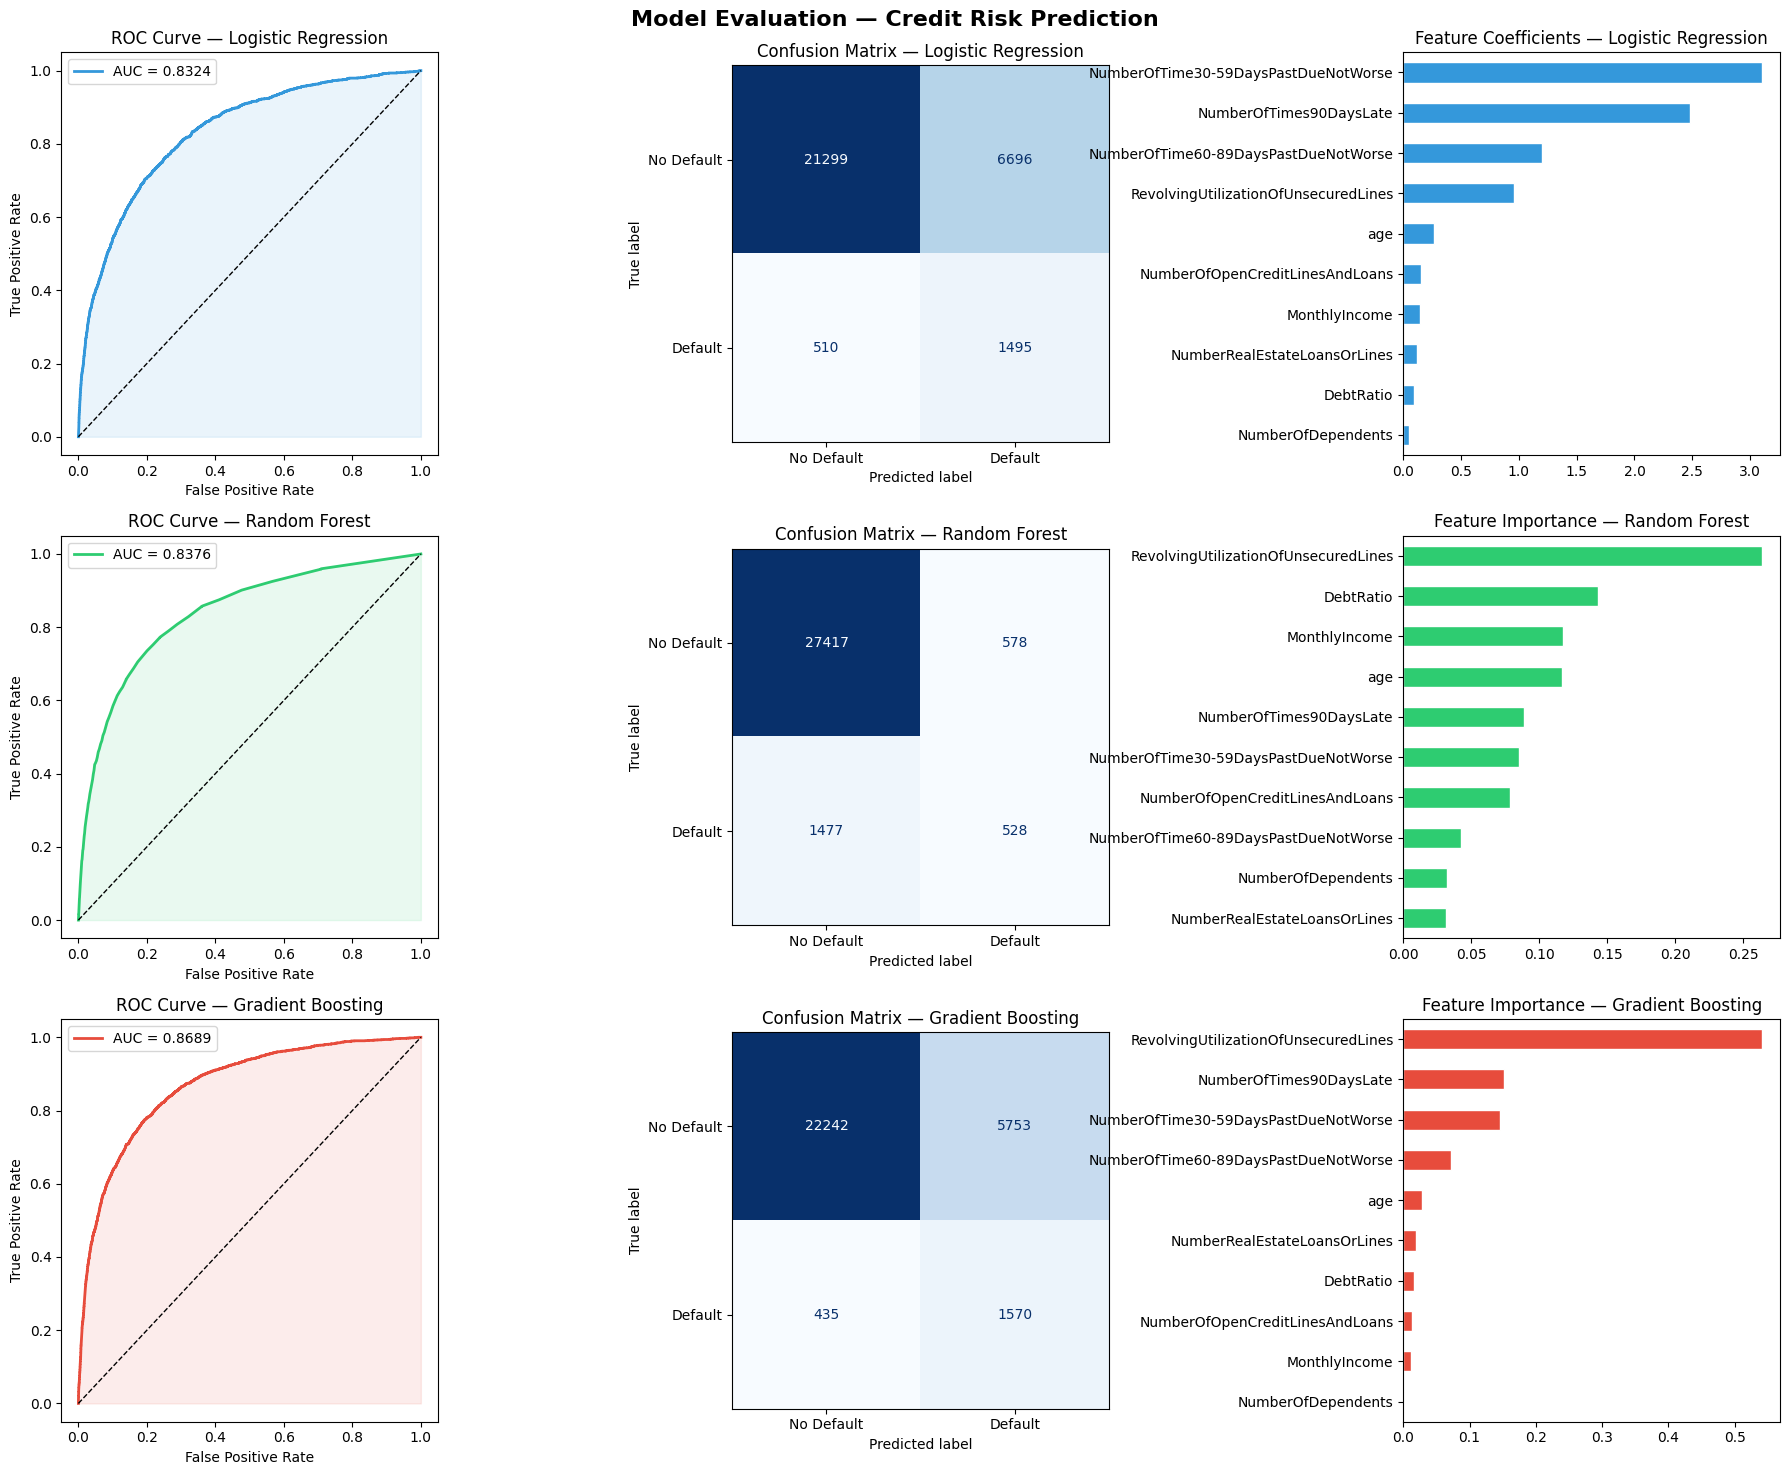

Done!


In [9]:
# Final Visualizations — All 3 models
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Model Evaluation — Credit Risk Prediction', fontsize=16, fontweight='bold')

model_names = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (name, res) in enumerate(results.items()):

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[i,0].plot(fpr, tpr, color=colors[i], linewidth=2,
                   label=f"AUC = {res['auc']:.4f}")
    axes[i,0].plot([0,1],[0,1],'k--', linewidth=1)
    axes[i,0].fill_between(fpr, tpr, alpha=0.1, color=colors[i])
    axes[i,0].set_title(f'ROC Curve — {name}')
    axes[i,0].set_xlabel('False Positive Rate')
    axes[i,0].set_ylabel('True Positive Rate')
    axes[i,0].legend(fontsize=10)

    # Confusion Matrix
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No Default','Default'])
    disp.plot(ax=axes[i,1], colorbar=False, cmap='Blues')
    axes[i,1].set_title(f'Confusion Matrix — {name}')

    # Feature Importance
    if hasattr(res['model'], 'feature_importances_'):
        feat_imp = pd.Series(
            res['model'].feature_importances_,
            index=X.columns
        ).sort_values(ascending=True)
        feat_imp.plot(kind='barh', ax=axes[i,2], color=colors[i], edgecolor='white')
        axes[i,2].set_title(f'Feature Importance — {name}')
    else:
        # Logistic Regression — use coefficients instead
        coef = pd.Series(
            np.abs(res['model'].coef_[0]),
            index=X.columns
        ).sort_values(ascending=True)
        coef.plot(kind='barh', ax=axes[i,2], color=colors[i], edgecolor='white')
        axes[i,2].set_title(f'Feature Coefficients — {name}')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [10]:
# Save model summary
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'AUC-ROC': [res['auc'] for res in results.values()]
}).sort_values('AUC-ROC', ascending=False)

print("=== Final Model Comparison ===")
print(summary.to_string(index=False))
print("\nBest model:", summary.iloc[0]['Model'])
print(f"Best AUC-ROC: {summary.iloc[0]['AUC-ROC']:.4f}")

=== Final Model Comparison ===
              Model  AUC-ROC
  Gradient Boosting 0.868887
      Random Forest 0.837614
Logistic Regression 0.832414

Best model: Gradient Boosting
Best AUC-ROC: 0.8689
